In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("DADS MP2 Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1328, 8)


,Date,Time,Description,Type,Amount,Balance,Mode,Ref
0,2024-01-01,03:11,AMAZON SELLER SVCS,Debit,₹2462,678275.0,UPI,TXN190872
1,01-Jan-24,05:44,BHIM-BMTC,DR,50.00,681007.0,UPI,TXN143064
2,01-Jan-24,09:35,NEFT-TECHCRUSH LABS-SALARY MAY24,CR,₹84728,484728.0,NEFT,TXN246316
3,2024-01-01,14:07,UPI-AMAN-8934@OKAXIS,Debit,₹1828,-748745.0,UPI,TXN569226
4,01 Jan 2024,14:23,BHIM-BLINKIT,Debit,270.00,680737.0,UPI,TXN968962


In [ ]:
print("Dataset Information")
print("=" * 50)

print(df.info())

print("\nColumn Names")
print("=" * 50)
print(df.columns.tolist())

print("\nMissing Values")
print("=" * 50)
print(df.isnull().sum())

print("\nDuplicate Rows")
print("=" * 50)
print("Duplicate rows:", df.duplicated().sum())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1328 non-null   object 
 1   Time         1328 non-null   object 
 2   Description  1328 non-null   object 
 3   Type         1328 non-null   object 
 4   Amount       1328 non-null   object 
 5   Balance      1328 non-null   float64
 6   Mode         1328 non-null   object 
 7   Ref          1328 non-null   object 
dtypes: float64(1), object(7)
memory usage: 83.1+ KB
None

Column Names
['Date', 'Time', 'Description', 'Type', 'Amount', 'Balance', 'Mode', 'Ref']

Missing Values
Date           0
Time           0
Description    0
Type           0
Amount         0
Balance        0
Mode           0
Ref            0
dtype: int64

Duplicate Rows
Duplicate rows: 18


In [ ]:
df['Date'] = pd.to_datetime(
    df['Date'],
    errors='coerce',
    dayfirst=True
)

print("Date column cleaned successfully!")
print("Date datatype:", df['Date'].dtype)
print("Unparseable dates:", df['Date'].isna().sum())

Date column cleaned successfully!
Date datatype: datetime64[ns]
Unparseable dates: 1184


In [ ]:
df['Amount'] = (
    df['Amount']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace('Rs.', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Amount'] = pd.to_numeric(
    df['Amount'],
    errors='coerce'
)

print("Amount column cleaned successfully!")
print("Amount datatype:", df['Amount'].dtype)
print("Unparseable amounts:", df['Amount'].isna().sum())

Amount column cleaned successfully!
Amount datatype: float64
Unparseable amounts: 0


In [ ]:
df['Type'] = (
    df['Type']
    .astype(str)
    .str.strip()
    .str.lower()
)

df['Type'] = df['Type'].replace({
    'dr': 'debit',
    'cr': 'credit',
    'debit': 'debit',
    'credit': 'credit'
})

print("Type column standardized successfully!")
print("\nTransaction Types:")
print(df['Type'].value_counts())

Type column standardized successfully!

Transaction Types:
Type
debit     1322
credit       6
Name: count, dtype: int64


In [ ]:
# Count duplicate rows before removing them
duplicate_count = df.duplicated().sum()

# Remove duplicate rows
df = df.drop_duplicates().copy()

print("Duplicate rows removed:", duplicate_count)
print("Remaining transactions:", len(df))

Duplicate rows removed: 18
Remaining transactions: 1310


In [ ]:
print("=" * 50)
print("CLEANED DATASET CHECK")
print("=" * 50)

print("Total transactions:", len(df))
print("Total columns:", len(df.columns))

print("\nColumn Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTransaction Types:")
print(df['Type'].value_counts())

print("\nFirst 5 Cleaned Transactions:")
print(df.head())

CLEANED DATASET CHECK
Total transactions: 1310
Total columns: 8

Column Data Types:
Date           datetime64[ns]
Time                   object
Description            object
Type                   object
Amount                float64
Balance               float64
Mode                   object
Ref                    object
dtype: object

Missing Values:
Date           1167
Time              0
Description       0
Type              0
Amount            0
Balance           0
Mode              0
Ref               0
dtype: int64

Duplicate Rows: 0

Transaction Types:
Type
debit     1304
credit       6
Name: count, dtype: int64

First 5 Cleaned Transactions:
        Date   Time                       Description    Type   Amount  \
0 2024-01-01  03:11                AMAZON SELLER SVCS   debit   2462.0   
1        NaT  05:44                         BHIM-BMTC   debit     50.0   
2        NaT  09:35  NEFT-TECHCRUSH LABS-SALARY MAY24  credit  84728.0   
3 2024-01-01  14:07              UPI-AMAN-893

In [ ]:
# Store the cleaned dataset
df_clean = df.copy()

print("=" * 60)
print("TRANSACTION PARSER - COMPLETE")
print("=" * 60)

print(f"Parsed {len(df_clean)} transactions")
print(f"Total columns: {len(df_clean.columns)}")
print(f"Dropped {duplicate_count} duplicate rows")
print(f"Unparseable dates: {df_clean['Date'].isna().sum()}")
print(f"Unparseable amounts: {df_clean['Amount'].isna().sum()}")
print(f"Remaining duplicate rows: {df_clean.duplicated().sum()}")

print("\nDate range:")
print(df_clean['Date'].min(), "to", df_clean['Date'].max())

print("\nTransaction types:")
print(df_clean['Type'].value_counts())

print("=" * 60)

TRANSACTION PARSER - COMPLETE
Parsed 1310 transactions
Total columns: 8
Dropped 18 duplicate rows
Unparseable dates: 1167
Unparseable amounts: 0
Remaining duplicate rows: 0

Date range:
2024-01-01 00:00:00 to 2024-12-06 00:00:00

Transaction types:
Type
debit     1304
credit       6
Name: count, dtype: int64


In [ ]:
# Display all unique transaction descriptions

unique_descriptions = df_clean['Description'].unique()

print("=" * 60)
print("UNIQUE TRANSACTION DESCRIPTIONS")
print("=" * 60)

print("Total unique descriptions:", len(unique_descriptions))
print()

for i, description in enumerate(unique_descriptions, start=1):
    print(f"{i}. {description}")

UNIQUE TRANSACTION DESCRIPTIONS
Total unique descriptions: 283

1. AMAZON SELLER SVCS
2. BHIM-BMTC
3. NEFT-TECHCRUSH LABS-SALARY MAY24
4. UPI-AMAN-8934@OKAXIS
5. BHIM-BLINKIT
6. BHIM ZEPTO
7. UPI-UBER-2426@HDFCBANK
8. POS SWIGGY BANGALORE
9. UPI-GROWWPAY@HDFCBANK
10. OLA ELECTRIC
11. BMS MOVIE TICKETS
12. POS OLA-PRIME
13. SWIGGY-INSTAMART
14. UPI-STARBUCKS@AXIS
15. UPI-THIRDWAVE@OKAXIS
16. ANI Technologies
17. BMTC BUS PASS
18. POS TRUFFLES
19. FLIPKART INDIA
20. POS SWIGGY-RESTAURANT
21. GROFERS INDIA P L
22. POS UBER BANGALORE
23. BANGALORE ELEC SUPPLY
24. TWC INDIA
25. UPI-BESCOM-BILL@HDFCBANK
26. UPI-AMAN-0816@OKAXIS
27. ROPPEN TRANSPORTATION
28. OLA CABS
29. POS ZOMATO
30. UPI-AMAZONPAY@HDFCBANK
31. POS BLINKIT
32. IMPS-RENT-LANDLORD-75500265
33. ZOMATO MEDIA P L
34. UPI-ANKIT-6430@OKAXIS
35. UPI-OLACABS@HDFCBANK
36. UPI-JIORECHARGE@PAYTM
37. UPI-CCD@HDFCBANK
38. Swiggy*Order
39. INSTAMART BANGALORE
40. UPI-ZOMATO-LIMITED@PAYTM
41. AVENUE SUPERMARTS
42. POS HP PETROL STATION
43. 

In [ ]:
vendor_keywords = {
    'Swiggy': ['SWIGGY', 'BUNDL'],
    'Zomato': ['ZOMATO'],
    'Amazon': ['AMAZON', 'AMZN'],
    'Zepto': ['ZEPTO'],
    'Zerodha': ['ZERODHA', 'COIN'],
    'Myntra': ['MYNTRA'],
    'BookMyShow': ['BOOKMYSHOW'],
    'Uber': ['UBER'],
    'Ola': ['OLA'],
    'Blinkit': ['BLINKIT'],
    'BigBasket': ['BIGBASKET'],
    'Netflix': ['NETFLIX'],
    'Spotify': ['SPOTIFY'],
    'YouTube': ['YOUTUBE'],
    'Google': ['GOOGLE'],
    'Jio': ['JIO'],
    'Airtel': ['AIRTEL'],
    'HPCL': ['HPCL'],
    'IndianOil': ['INDIANOIL'],
    'PVR': ['PVR'],
    'Dominos': ['DOMINOS'],
    'KFC': ['KFC'],
    'McDonalds': ['MCDONALDS'],
    'Starbucks': ['STARBUCKS']
}

print("Vendor dictionary created successfully!")
print("Number of vendors:", len(vendor_keywords))

print("\nVendor Keywords:")
for vendor, keywords in vendor_keywords.items():
    print(f"{vendor}: {keywords}")

Vendor dictionary created successfully!
Number of vendors: 24

Vendor Keywords:
Swiggy: ['SWIGGY', 'BUNDL']
Zomato: ['ZOMATO']
Amazon: ['AMAZON', 'AMZN']
Zepto: ['ZEPTO']
Zerodha: ['ZERODHA', 'COIN']
Myntra: ['MYNTRA']
BookMyShow: ['BOOKMYSHOW']
Uber: ['UBER']
Ola: ['OLA']
Blinkit: ['BLINKIT']
BigBasket: ['BIGBASKET']
Netflix: ['NETFLIX']
Spotify: ['SPOTIFY']
YouTube: ['YOUTUBE']
Google: ['GOOGLE']
Jio: ['JIO']
Airtel: ['AIRTEL']
HPCL: ['HPCL']
IndianOil: ['INDIANOIL']
PVR: ['PVR']
Dominos: ['DOMINOS']
KFC: ['KFC']
McDonalds: ['MCDONALDS']
Starbucks: ['STARBUCKS']


In [ ]:
vendor_keywords.update({
    'BMTC': ['BMTC', 'TUMMOC'],
    'TechCrush Labs': ['TECHCRUSH LABS'],
    'BookMyShow': ['BMS MOVIE TICKETS', 'BIGTREE ENTERTAINMENT'],
    'Ola': ['ANI TECHNOLOGIES'],
    'Truffles': ['TRUFFLES'],
    'Flipkart': ['FLIPKART', 'FKART'],
    'Grofers': ['GROFERS'],
    'Bangalore Electricity': ['BANGALORE ELEC SUPPLY'],
    'TWC': ['TWC INDIA'],
    'Roppen': ['ROPPEN TRANSPORTATION'],
    'Instamart': ['INSTAMART'],
    'DMart': ['AVENUE SUPERMARTS', 'DMART', 'INNOVATIVE RETAIL'],
    'HP Petrol': ['HP PETROL'],
    'BPCL': ['BPCL'],
    'Bangalore Restaurant': ['BANGALORE RESTAURANT'],
    'Cafe Coffee Day': ['CAFE COFFEE DAY', 'COFFEE DAY GLOBAL'],
    'Nykaa': ['NYKAA'],
    'Vi': ['VI POSTPAID', 'VODAFONE IDEA'],
    'IndianOil': ['INDIAN OIL', 'INDIANOIL'],
    'Dineout': ['DINEOUT'],
    'Disney+ Hotstar': ['DISNEY HOTSTAR'],
    'Empire Restaurant': ['EMPIRE RESTAURANT'],
    'Meghana Foods': ['MEGHANA FOODS'],
    'Third Wave Coffee': ['THIRD WAVE COFFEE'],
    'BESCOM': ['BESCOM'],
    'FSN E-Commerce': ['FSN E-COMMERCE'],
    'Star India': ['STAR INDIA'],
    'KiranaKart': ['KIRANAKART'],
    'BWSSB': ['BWSSB'],
    'Groww': ['GROWW', 'NEXTBILLION'],
})

In [ ]:
vendor_keywords.update({
    'Ola': ['OLA', 'ANI TECHNOLOGIES'],
    'Rapido': ['RAPIDO'],
    'Rent': ['RENT', 'LANDLORD']
})

In [ ]:
def extract_vendor(description):
    description = str(description).upper()

    # Check for ATM withdrawals
    if 'ATM-WDL' in description or 'ATM WDL' in description:
        return 'Cash Withdrawal'

    # Check for P2P transfers
    if 'UPI-' in description:
        parts = description.split('-')

        if len(parts) > 1:
            possible_person = parts[1]

            # If it doesn't match a known vendor, treat as P2P
            known_vendor = False

            for vendor, keywords in vendor_keywords.items():
                for keyword in keywords:
                    if keyword in description:
                        known_vendor = True
                        break

                if known_vendor:
                    break

            if not known_vendor:
                return 'P2P Transfer'

    # Check known vendors
    for vendor, keywords in vendor_keywords.items():
        for keyword in keywords:
            if keyword in description:
                return vendor

    # If no vendor matches
    return 'Uncategorised'


print("extract_vendor() function created successfully!")

extract_vendor() function created successfully!


In [ ]:
print("=" * 60)
print("VENDOR EXTRACTION TEST")
print("=" * 60)

test_descriptions = df_clean['Description'].head(10)

for description in test_descriptions:
    vendor = extract_vendor(description)
    print(f"Description: {description}")
    print(f"Vendor     : {vendor}")
    print("-" * 60)

VENDOR EXTRACTION TEST
Description: AMAZON SELLER SVCS
Vendor     : Amazon
------------------------------------------------------------
Description: BHIM-BMTC
Vendor     : BMTC
------------------------------------------------------------
Description: NEFT-TECHCRUSH LABS-SALARY MAY24
Vendor     : TechCrush Labs
------------------------------------------------------------
Description: UPI-AMAN-8934@OKAXIS
Vendor     : P2P Transfer
------------------------------------------------------------
Description: BHIM-BLINKIT
Vendor     : Blinkit
------------------------------------------------------------
Description: BHIM ZEPTO
Vendor     : Zepto
------------------------------------------------------------
Description: UPI-UBER-2426@HDFCBANK
Vendor     : Uber
------------------------------------------------------------
Description: BHIM-BLINKIT
Vendor     : Blinkit
------------------------------------------------------------
Description: POS SWIGGY BANGALORE
Vendor     : Swiggy
-----------------

In [ ]:
df_clean['vendor_clean'] = df_clean['Description'].apply(extract_vendor)


print("=" * 60)
print("VENDOR EXTRACTION COMPLETED")
print("=" * 60)

print("Total transactions:", len(df_clean))
print("Unique vendors found:", df_clean['vendor_clean'].nunique())

print("\nVendor counts:")
print(df_clean['vendor_clean'].value_counts())

VENDOR EXTRACTION COMPLETED
Total transactions: 1310
Unique vendors found: 48

Vendor counts:
vendor_clean
Swiggy                   223
Zomato                   121
Ola                       87
Amazon                    86
P2P Transfer              72
Uber                      71
Zepto                     58
Flipkart                  47
Starbucks                 42
Rapido                    41
Blinkit                   40
BMTC                      37
DMart                     30
Instamart                 20
Myntra                    20
Cafe Coffee Day           17
Cash Withdrawal           17
Nykaa                     16
Grofers                   15
Zerodha                   14
Roppen                    14
KiranaKart                13
Empire Restaurant         13
Bangalore Restaurant      12
Meghana Foods             12
BigBasket                 11
IndianOil                 11
Third Wave Coffee         11
Netflix                   10
Dineout                   10
BookMyShow             

In [ ]:
df_clean['vendor_clean'] = df_clean['Description'].apply(extract_vendor)

print("Unique vendors:", df_clean['vendor_clean'].nunique())
print("Uncategorised transactions:",
      (df_clean['vendor_clean'] == 'Uncategorised').sum())

Unique vendors: 48
Uncategorised transactions: 0


In [ ]:
uncategorised = df_clean[
    df_clean['vendor_clean'] == 'Uncategorised'
]

print("=" * 60)
print("UNCATEGORISED TRANSACTIONS")
print("=" * 60)

print("Number of uncategorised transactions:", len(uncategorised))

print("\nUnique uncategorised descriptions:")
for description in uncategorised['Description'].unique():
    print("-", description)

UNCATEGORISED TRANSACTIONS
Number of uncategorised transactions: 0

Unique uncategorised descriptions:


In [ ]:
print("=" * 60)
print("VENDOR EXTRACTOR - FINAL CHECK")
print("=" * 60)

print("Total transactions:", len(df_clean))
print("Unique vendors:", df_clean['vendor_clean'].nunique())
print("Uncategorised transactions:",
      (df_clean['vendor_clean'] == 'Uncategorised').sum())

print("\nTop 15 Vendors:")
print(df_clean['vendor_clean'].value_counts().head(15))

VENDOR EXTRACTOR - FINAL CHECK
Total transactions: 1310
Unique vendors: 48
Uncategorised transactions: 0

Top 15 Vendors:
vendor_clean
Swiggy          223
Zomato          121
Ola              87
Amazon           86
P2P Transfer     72
Uber             71
Zepto            58
Flipkart         47
Starbucks        42
Rapido           41
Blinkit          40
BMTC             37
DMart            30
Instamart        20
Myntra           20
Name: count, dtype: int64


In [ ]:
vendor_categories = {

    # Food Delivery
    'Swiggy': 'Food Delivery',
    'Zomato': 'Food Delivery',

    # Dining / Cafes
    'Starbucks': 'Dining/Cafes',
    'Cafe Coffee Day': 'Dining/Cafes',
    'Third Wave Coffee': 'Dining/Cafes',
    'Truffles': 'Dining/Cafes',
    'Empire Restaurant': 'Dining/Cafes',
    'Meghana Foods': 'Dining/Cafes',
    'Bangalore Restaurant': 'Dining/Cafes',
    'Dineout': 'Dining/Cafes',
    'Dominos': 'Dining/Cafes',
    'KFC': 'Dining/Cafes',
    'McDonalds': 'Dining/Cafes',

    # Groceries
    'Zepto': 'Groceries',
    'Blinkit': 'Groceries',
    'Instamart': 'Groceries',
    'Grofers': 'Groceries',
    'BigBasket': 'Groceries',
    'DMart': 'Groceries',
    'KiranaKart': 'Groceries',

    # Shopping
    'Amazon': 'Shopping',
    'Flipkart': 'Shopping',
    'Myntra': 'Shopping',
    'Nykaa': 'Shopping',
    'FSN E-Commerce': 'Shopping',

    # Transport
    'Ola': 'Transport',
    'Uber': 'Transport',
    'Rapido': 'Transport',
    'BMTC': 'Transport',
    'Roppen': 'Transport',
    'HP Petrol': 'Transport',
    'BPCL': 'Transport',
    'IndianOil': 'Transport',

    # Entertainment
    'BookMyShow': 'Entertainment',
    'Disney+ Hotstar': 'Entertainment',
    'PVR': 'Entertainment',
    'Star India': 'Entertainment',

    # Utilities
    'BESCOM': 'Utilities',
    'BWSSB': 'Utilities',
    'Bangalore Electricity': 'Utilities',
    'Airtel': 'Utilities',
    'Vi': 'Utilities',
    'Jio': 'Utilities',

    # Investments
    'Zerodha': 'Investments',
    'Groww': 'Investments',

    # Subscriptions
    'Netflix': 'Subscriptions',
    'Spotify': 'Subscriptions',
    'YouTube': 'Subscriptions',
    'Google': 'Subscriptions',

    # Rent
    'Rent': 'Rent',

    # P2P Transfers
    'P2P Transfer': 'P2P Transfers',

    # Cash Withdrawal
    'Cash Withdrawal': 'Cash Withdrawal'
}

print("Category dictionary created!")
print("Vendors mapped:", len(vendor_categories))

Category dictionary created!
Vendors mapped: 52


In [ ]:
vendor_categories.update({
    'TWC': 'Shopping',
    'TechCrush Labs': 'Shopping'
})

print("Missing vendor categories added!")

Missing vendor categories added!


In [ ]:
# Get the actual vendors present in our dataset
actual_vendors = set(df_clean['vendor_clean'].unique())

# Get vendors that have category mappings
mapped_vendors = set(vendor_categories.keys())

# Find vendors present in the dataset but missing from the dictionary
unmapped_vendors = actual_vendors - mapped_vendors

print("=" * 60)
print("CATEGORY MAPPING CHECK")
print("=" * 60)

print("Actual vendors in dataset:", len(actual_vendors))
print("Vendors in category dictionary:", len(mapped_vendors))
print("Unmapped vendors:", len(unmapped_vendors))

print("\nUnmapped vendors:")
for vendor in sorted(unmapped_vendors):
    print("-", vendor)

CATEGORY MAPPING CHECK
Actual vendors in dataset: 48
Vendors in category dictionary: 54
Unmapped vendors: 0

Unmapped vendors:


In [ ]:
df_clean['category'] = df_clean['vendor_clean'].map(vendor_categories)

print("=" * 60)
print("CATEGORY COLUMN CREATED")
print("=" * 60)

print("Total transactions:", len(df_clean))
print("Missing categories:", df_clean['category'].isna().sum())

print("\nCategory counts:")
print(df_clean['category'].value_counts())

CATEGORY COLUMN CREATED
Total transactions: 1310
Missing categories: 0

Category counts:
category
Food Delivery      344
Transport          272
Groceries          187
Shopping           187
Dining/Cafes       126
P2P Transfers       72
Utilities           40
Investments         23
Entertainment       18
Subscriptions       18
Cash Withdrawal     17
Rent                 6
Name: count, dtype: int64


In [ ]:
required_categories = [
    'Food Delivery',
    'Dining/Cafes',
    'Groceries',
    'Shopping',
    'Transport',
    'Entertainment',
    'Utilities',
    'Investments',
    'Subscriptions',
    'Rent',
    'P2P Transfers',
    'Cash Withdrawal',
    'Other'
]

print("=" * 60)
print("CATEGORY VERIFICATION")
print("=" * 60)

for category in required_categories:
    count = (df_clean['category'] == category).sum()
    print(f"{category:<20} : {count}")

CATEGORY VERIFICATION
Food Delivery        : 344
Dining/Cafes         : 126
Groceries            : 187
Shopping             : 187
Transport            : 272
Entertainment        : 18
Utilities            : 40
Investments          : 23
Subscriptions        : 18
Rent                 : 6
P2P Transfers        : 72
Cash Withdrawal      : 17
Other                : 0


In [ ]:
total_credits = df_clean.loc[
    df_clean['Type'] == 'credit',
    'Amount'
].sum()

print("Total Credits: ₹", round(total_credits, 2))

Total Credits: ₹ 509774.0


In [ ]:
total_debits = df_clean.loc[
    df_clean['Type'] == 'debit',
    'Amount'
].sum()

print("Total Debits: ₹", round(total_debits, 2))

Total Debits: ₹ 1678901.0


In [ ]:
net_savings = total_credits - total_debits

print("Total Credits : ₹", round(total_credits, 2))
print("Total Debits  : ₹", round(total_debits, 2))
print("Net Savings   : ₹", round(net_savings, 2))

Total Credits : ₹ 509774.0
Total Debits  : ₹ 1678901.0
Net Savings   : ₹ -1169127.0


In [ ]:
savings_rate = (net_savings / total_credits) * 100

print("Savings Rate:", round(savings_rate, 2), "%")

Savings Rate: -229.34 %


In [ ]:
print("=" * 50)
print("SPENDING OVERVIEW CHECK")
print("=" * 50)

print("Total Credits :", round(total_credits, 2))
print("Total Debits  :", round(total_debits, 2))
print("Net Savings   :", round(net_savings, 2))
print("Savings Rate  :", round(savings_rate, 2), "%")

SPENDING OVERVIEW CHECK
Total Credits : 509774.0
Total Debits  : 1678901.0
Net Savings   : -1169127.0
Savings Rate  : -229.34 %


In [ ]:
print("\nTransaction Type Counts:")
print(df_clean['Type'].value_counts())


Transaction Type Counts:
Type
debit     1304
credit       6
Name: count, dtype: int64


In [ ]:
top_categories = (
    df_clean[df_clean['Type'] == 'debit']
    .groupby('category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("=" * 60)
print("TOP 5 SPENDING CATEGORIES")
print("=" * 60)

print(top_categories)

TOP 5 SPENDING CATEGORIES
category
Shopping         607167.0
Investments      248160.0
Food Delivery    150839.0
Groceries        133289.0
Transport        131729.0
Name: Amount, dtype: float64


In [ ]:
top_vendors = (
    df_clean[df_clean['Type'] == 'debit']
    .groupby('vendor_clean')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("=" * 60)
print("TOP 5 VENDORS BY SPENDING")
print("=" * 60)

print(top_vendors)

TOP 5 VENDORS BY SPENDING
vendor_clean
Amazon      328530.0
Zerodha     210000.0
Flipkart    177510.0
Rent        108000.0
Swiggy       95523.0
Name: Amount, dtype: float64


In [ ]:
top_vendors = (
    df_clean[df_clean['Type'] == 'debit']
    .groupby('vendor_clean')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("=" * 60)
print("TOP 5 VENDORS BY SPENDING")
print("=" * 60)

print(top_vendors)

TOP 5 VENDORS BY SPENDING
vendor_clean
Amazon      328530.0
Zerodha     210000.0
Flipkart    177510.0
Rent        108000.0
Swiggy       95523.0
Name: Amount, dtype: float64


In [ ]:
print("=" * 70)
print("                 SPENDING OVERVIEW")
print("=" * 70)

print(f"Total Credits       : ₹{total_credits:,.2f}")
print(f"Total Debits        : ₹{total_debits:,.2f}")
print(f"Net Savings         : ₹{net_savings:,.2f}")
print(f"Savings Rate        : {savings_rate:.2f}%")

print("\nTop 5 Spending Categories:")
print(top_categories)

print("\nTop 5 Vendors by Spending:")
print(top_vendors)

print("=" * 70)

                 SPENDING OVERVIEW
Total Credits       : ₹509,774.00
Total Debits        : ₹1,678,901.00
Net Savings         : ₹-1,169,127.00
Savings Rate        : -229.34%

Top 5 Spending Categories:
category
Shopping         607167.0
Investments      248160.0
Food Delivery    150839.0
Groceries        133289.0
Transport        131729.0
Name: Amount, dtype: float64

Top 5 Vendors by Spending:
vendor_clean
Amazon      328530.0
Zerodha     210000.0
Flipkart    177510.0
Rent        108000.0
Swiggy       95523.0
Name: Amount, dtype: float64


In [ ]:
df_clean['Month'] = df_clean['Date'].dt.to_period('M')

print("=" * 60)
print("MONTH COLUMN CREATED")
print("=" * 60)

print("Unique months:", df_clean['Month'].nunique())

print("\nMonths:")
print(df_clean['Month'].unique())

MONTH COLUMN CREATED
Unique months: 12

Months:
<PeriodArray>
['2024-01',     'NaT', '2024-02', '2024-03', '2024-04', '2024-05', '2024-07',
 '2024-08', '2024-09', '2024-10', '2024-12', '2024-06', '2024-11']
Length: 13, dtype: period[M]


In [ ]:
monthly_spending = (
    df_clean[
        (df_clean['Type'] == 'debit') &
        (df_clean['Month'].notna())
    ]
    .groupby('Month')['Amount']
    .sum()
    .sort_index()
)

print("=" * 60)
print("MONTHLY SPENDING")
print("=" * 60)

print(monthly_spending)

MONTHLY SPENDING
Month
2024-01    14972.0
2024-02     6390.0
2024-03    26578.0
2024-04     5246.0
2024-05    21011.0
2024-06     9292.0
2024-07    23632.0
2024-08    41383.0
2024-09    14154.0
2024-10     5541.0
2024-11     6366.0
2024-12    30745.0
Freq: M, Name: Amount, dtype: float64


In [ ]:
highest_spending_month = monthly_spending.idxmax()
highest_spending_amount = monthly_spending.max()

lowest_spending_month = monthly_spending.idxmin()
lowest_spending_amount = monthly_spending.min()

print("=" * 60)
print("MONTHLY SPENDING EXTREMES")
print("=" * 60)

print(f"Highest Spending Month : {highest_spending_month}")
print(f"Highest Spending Amount: ₹{highest_spending_amount:,.2f}")

print(f"\nLowest Spending Month  : {lowest_spending_month}")
print(f"Lowest Spending Amount : ₹{lowest_spending_amount:,.2f}")

MONTHLY SPENDING EXTREMES
Highest Spending Month : 2024-08
Highest Spending Amount: ₹41,383.00

Lowest Spending Month  : 2024-04
Lowest Spending Amount : ₹5,246.00


In [ ]:
print("=" * 60)
print("MONTHLY SPENDING TREND")
print("=" * 60)

for month, amount in monthly_spending.items():
    print(f"{month}: ₹{amount:,.2f}")

MONTHLY SPENDING TREND
2024-01: ₹14,972.00
2024-02: ₹6,390.00
2024-03: ₹26,578.00
2024-04: ₹5,246.00
2024-05: ₹21,011.00
2024-06: ₹9,292.00
2024-07: ₹23,632.00
2024-08: ₹41,383.00
2024-09: ₹14,154.00
2024-10: ₹5,541.00
2024-11: ₹6,366.00
2024-12: ₹30,745.00


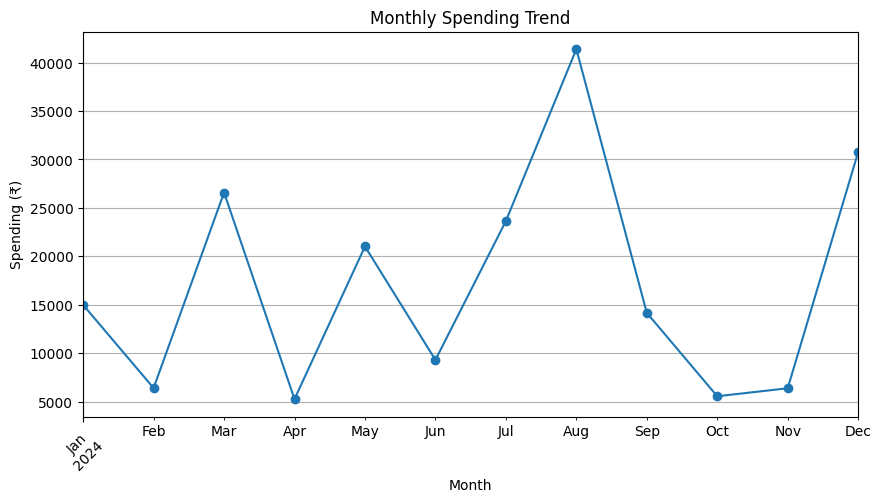

In [ ]:
import matplotlib.pyplot as plt

monthly_spending.plot(
    kind='line',
    marker='o',
    figsize=(10, 5),
    title='Monthly Spending Trend'
)

plt.xlabel('Month')
plt.ylabel('Spending (₹)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
monthly_change = monthly_spending.pct_change() * 100

print("=" * 60)
print("MONTH-OVER-MONTH SPENDING CHANGE")
print("=" * 60)

print(monthly_change.round(2))

MONTH-OVER-MONTH SPENDING CHANGE
Month
2024-01       NaN
2024-02    -57.32
2024-03    315.93
2024-04    -80.26
2024-05    300.51
2024-06    -55.78
2024-07    154.33
2024-08     75.11
2024-09    -65.80
2024-10    -60.85
2024-11     14.89
2024-12    382.96
Freq: M, Name: Amount, dtype: float64


In [ ]:
biggest_increase_month = monthly_change.dropna().idxmax()
biggest_increase = monthly_change.dropna().max()

biggest_decrease_month = monthly_change.dropna().idxmin()
biggest_decrease = monthly_change.dropna().min()

print("=" * 60)
print("BIGGEST MONTHLY CHANGES")
print("=" * 60)

print(f"Biggest Increase : {biggest_increase_month} ({biggest_increase:.2f}%)")
print(f"Biggest Decrease : {biggest_decrease_month} ({biggest_decrease:.2f}%)")

BIGGEST MONTHLY CHANGES
Biggest Increase : 2024-12 (382.96%)
Biggest Decrease : 2024-04 (-80.26%)


In [ ]:
print("=" * 70)
print("                 MONTHLY TREND ANALYSIS")
print("=" * 70)

print("\nMonthly Spending:")
print(monthly_spending)

print(f"\nHighest Spending Month : {highest_spending_month}")
print(f"Highest Spending Amount: ₹{highest_spending_amount:,.2f}")

print(f"\nLowest Spending Month  : {lowest_spending_month}")
print(f"Lowest Spending Amount : ₹{lowest_spending_amount:,.2f}")

print(f"\nBiggest Monthly Increase: {biggest_increase_month} ({biggest_increase:.2f}%)")
print(f"Biggest Monthly Decrease: {biggest_decrease_month} ({biggest_decrease:.2f}%)")

print("=" * 70)

                 MONTHLY TREND ANALYSIS

Monthly Spending:
Month
2024-01    14972.0
2024-02     6390.0
2024-03    26578.0
2024-04     5246.0
2024-05    21011.0
2024-06     9292.0
2024-07    23632.0
2024-08    41383.0
2024-09    14154.0
2024-10     5541.0
2024-11     6366.0
2024-12    30745.0
Freq: M, Name: Amount, dtype: float64

Highest Spending Month : 2024-08
Highest Spending Amount: ₹41,383.00

Lowest Spending Month  : 2024-04
Lowest Spending Amount : ₹5,246.00

Biggest Monthly Increase: 2024-12 (382.96%)
Biggest Monthly Decrease: 2024-04 (-80.26%)


In [ ]:
vendor_spending = (
    df_clean[df_clean['Type'] == 'debit']
    .groupby('vendor_clean')['Amount']
    .sum()
    .sort_values(ascending=False)
)

print("=" * 60)
print("VENDOR SPENDING SUMMARY")
print("=" * 60)

print(vendor_spending)

VENDOR SPENDING SUMMARY
vendor_clean
Amazon                   328530.0
Zerodha                  210000.0
Flipkart                 177510.0
Rent                     108000.0
Swiggy                    95523.0
P2P Transfer              71189.0
Myntra                    69529.0
Zomato                    55316.0
DMart                     46662.0
Cash Withdrawal           45500.0
IndianOil                 41287.0
Groww                     38160.0
Zepto                     28157.0
Bangalore Restaurant      27528.0
Ola                       26782.0
Nykaa                     24012.0
Uber                      23770.0
Blinkit                   23104.0
Meghana Foods             22341.0
Dineout                   19825.0
HP Petrol                 17895.0
Truffles                  16673.0
BESCOM                    16560.0
BPCL                      15073.0
Starbucks                 15046.0
Empire Restaurant         13920.0
BigBasket                 12745.0
Bangalore Electricity     11412.0
Grofers    

In [ ]:
top_10_vendors = vendor_spending.head(10)

print("=" * 60)
print("TOP 10 VENDORS BY SPENDING")
print("=" * 60)

for vendor, amount in top_10_vendors.items():
    print(f"{vendor:<25} ₹{amount:,.2f}")

TOP 10 VENDORS BY SPENDING
Amazon                    ₹328,530.00
Zerodha                   ₹210,000.00
Flipkart                  ₹177,510.00
Rent                      ₹108,000.00
Swiggy                    ₹95,523.00
P2P Transfer              ₹71,189.00
Myntra                    ₹69,529.00
Zomato                    ₹55,316.00
DMart                     ₹46,662.00
Cash Withdrawal           ₹45,500.00


In [ ]:
vendor_percentage = (
    vendor_spending / vendor_spending.sum()
) * 100

top_10_percentage = vendor_percentage.head(10)

print("=" * 60)
print("TOP 10 VENDORS - PERCENTAGE OF TOTAL SPENDING")
print("=" * 60)

for vendor, percentage in top_10_percentage.items():
    print(f"{vendor:<25} {percentage:.2f}%")

TOP 10 VENDORS - PERCENTAGE OF TOTAL SPENDING
Amazon                    19.57%
Zerodha                   12.51%
Flipkart                  10.57%
Rent                      6.43%
Swiggy                    5.69%
P2P Transfer              4.24%
Myntra                    4.14%
Zomato                    3.29%
DMart                     2.78%
Cash Withdrawal           2.71%


In [ ]:
highest_vendor = vendor_spending.idxmax()
highest_vendor_amount = vendor_spending.max()

print("=" * 60)
print("HIGHEST SPENDING VENDOR")
print("=" * 60)

print("Vendor:", highest_vendor)
print(f"Amount spent: ₹{highest_vendor_amount:,.2f}")


HIGHEST SPENDING VENDOR
Vendor: Amazon
Amount spent: ₹328,530.00


In [ ]:
lowest_vendor = vendor_spending.idxmin()
lowest_vendor_amount = vendor_spending.min()

print("=" * 60)
print("LOWEST SPENDING VENDOR")
print("=" * 60)

print("Vendor:", lowest_vendor)
print(f"Amount spent: ₹{lowest_vendor_amount:,.2f}")

LOWEST SPENDING VENDOR
Vendor: Spotify
Amount spent: ₹952.00


In [ ]:
top_5_total = top_10_vendors.head(5).sum()
total_vendor_spending = vendor_spending.sum()

top_5_percentage = (top_5_total / total_vendor_spending) * 100

print("=" * 60)
print("TOP 5 VENDOR SPENDING CONCENTRATION")
print("=" * 60)

print(f"Top 5 vendor spending : ₹{top_5_total:,.2f}")
print(f"Total vendor spending : ₹{total_vendor_spending:,.2f}")
print(f"Top 5 share           : {top_5_percentage:.2f}%")

TOP 5 VENDOR SPENDING CONCENTRATION
Top 5 vendor spending : ₹919,563.00
Total vendor spending : ₹1,678,901.00
Top 5 share           : 54.77%


In [ ]:
print("=" * 70)
print("                 VENDOR ANALYSIS")
print("=" * 70)

print(f"Total Vendors              : {vendor_spending.nunique()}")
print(f"Highest Spending Vendor    : {highest_vendor}")
print(f"Highest Vendor Spending    : ₹{highest_vendor_amount:,.2f}")

print(f"\nLowest Spending Vendor     : {lowest_vendor}")
print(f"Lowest Vendor Spending     : ₹{lowest_vendor_amount:,.2f}")

print(f"\nTop 5 Vendor Spending      : ₹{top_5_total:,.2f}")
print(f"Total Vendor Spending      : ₹{total_vendor_spending:,.2f}")
print(f"Top 5 Spending Share       : {top_5_percentage:.2f}%")

print("\nTop 10 Vendors:")
for vendor, amount in top_10_vendors.items():
    print(f"{vendor:<25} ₹{amount:,.2f}")

print("=" * 70)

                 VENDOR ANALYSIS
Total Vendors              : 47
Highest Spending Vendor    : Amazon
Highest Vendor Spending    : ₹328,530.00

Lowest Spending Vendor     : Spotify
Lowest Vendor Spending     : ₹952.00

Top 5 Vendor Spending      : ₹919,563.00
Total Vendor Spending      : ₹1,678,901.00
Top 5 Spending Share       : 54.77%

Top 10 Vendors:
Amazon                    ₹328,530.00
Zerodha                   ₹210,000.00
Flipkart                  ₹177,510.00
Rent                      ₹108,000.00
Swiggy                    ₹95,523.00
P2P Transfer              ₹71,189.00
Myntra                    ₹69,529.00
Zomato                    ₹55,316.00
DMart                     ₹46,662.00
Cash Withdrawal           ₹45,500.00


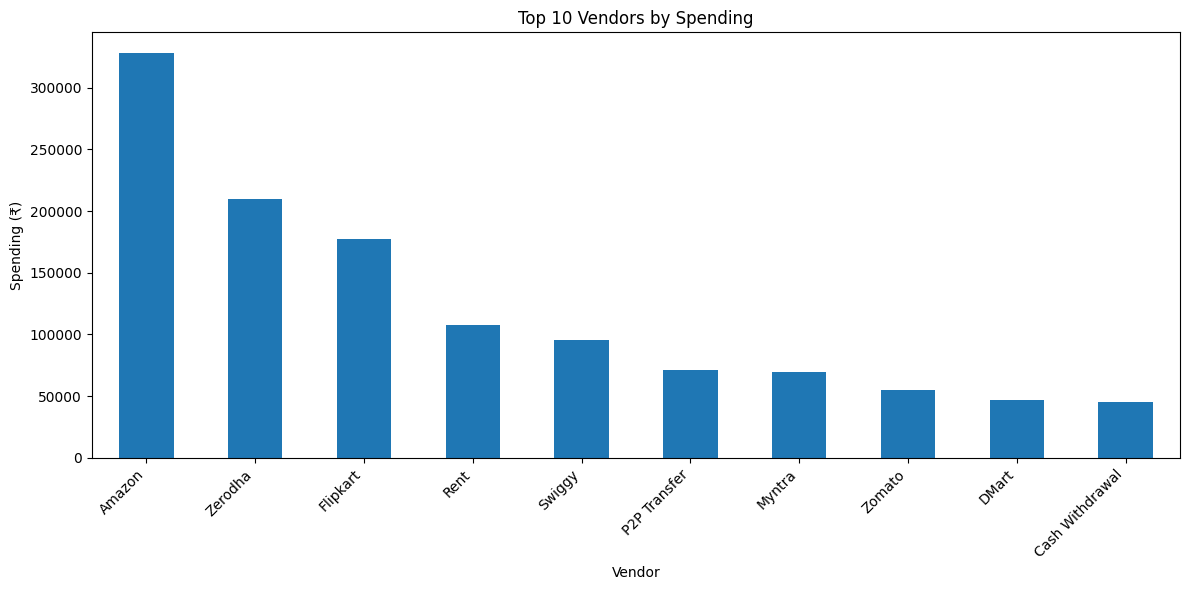

In [ ]:
top_10_vendors.plot(
    kind='bar',
    figsize=(12, 6),
    title='Top 10 Vendors by Spending'
)

plt.xlabel('Vendor')
plt.ylabel('Spending (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 70)
print("                 VENDOR ANALYSIS - FINAL")
print("=" * 70)

print(f"Total Vendors             : {len(vendor_spending)}")

print(f"\nHighest Spending Vendor   : {highest_vendor}")
print(f"Highest Vendor Spending   : ₹{highest_vendor_amount:,.2f}")

print(f"\nLowest Spending Vendor    : {lowest_vendor}")
print(f"Lowest Vendor Spending    : ₹{lowest_vendor_amount:,.2f}")

print(f"\nTop 5 Vendor Spending     : ₹{top_5_total:,.2f}")
print(f"Total Spending            : ₹{total_vendor_spending:,.2f}")
print(f"Top 5 Spending Share      : {top_5_percentage:.2f}%")

print("\nTop 10 Vendors:")
for vendor, amount in top_10_vendors.items():
    print(f"{vendor:<25} ₹{amount:,.2f}")

print("=" * 70)

                 VENDOR ANALYSIS - FINAL
Total Vendors             : 47

Highest Spending Vendor   : Amazon
Highest Vendor Spending   : ₹328,530.00

Lowest Spending Vendor    : Spotify
Lowest Vendor Spending    : ₹952.00

Top 5 Vendor Spending     : ₹919,563.00
Total Spending            : ₹1,678,901.00
Top 5 Spending Share      : 54.77%

Top 10 Vendors:
Amazon                    ₹328,530.00
Zerodha                   ₹210,000.00
Flipkart                  ₹177,510.00
Rent                      ₹108,000.00
Swiggy                    ₹95,523.00
P2P Transfer              ₹71,189.00
Myntra                    ₹69,529.00
Zomato                    ₹55,316.00
DMart                     ₹46,662.00
Cash Withdrawal           ₹45,500.00
